In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.random.randn(500, 2)
y = ((X[:, 0]**2 + X[:, 1]**2) > 1).astype(int)

Y = np.eye(2)[y]

print(X.shape, Y.shape)

(500, 2) (500, 2)


In [2]:
layers = [2, 16, 16, 2]
W, b = [], []

for i in range(len(layers)-1):
    W.append(np.random.randn(layers[i], layers[i+1]) *
             np.sqrt(2/layers[i]))
    b.append(np.zeros((1, layers[i+1])))

In [3]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=1, keepdims=True)

In [4]:
def forward(X):
    A = [X]
    Z = []

    for i in range(len(W)-1):
        z = A[-1] @ W[i] + b[i]
        Z.append(z)
        A.append(relu(z))

    z = A[-1] @ W[-1] + b[-1]
    Z.append(z)
    A.append(softmax(z))

    return A, Z

In [5]:
def backward(Y, A, Z):
    dW = [None] * len(W)
    db = [None] * len(W)

    dz = A[-1] - Y
    m = len(Y)

    for i in range(len(W)-1, -1, -1):
        dW[i] = A[i].T @ dz / m
        db[i] = np.sum(dz, axis=0, keepdims=True) / m

        if i > 0:
            dz = (dz @ W[i].T) * relu_grad(Z[i-1])

    return dW, db

In [6]:
lr = 0.05
losses = []

for epoch in range(1000):

    A, Z = forward(X)

    loss = -np.mean(
        np.sum(Y * np.log(A[-1] + 1e-8), axis=1)
    )

    dW, db = backward(Y, A, Z)

    for i in range(len(W)):
        W[i] -= lr * dW[i]
        b[i] -= lr * db[i]

    losses.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 0.9759
Epoch 100, Loss: 0.3752
Epoch 200, Loss: 0.2435
Epoch 300, Loss: 0.1698
Epoch 400, Loss: 0.1333
Epoch 500, Loss: 0.1110
Epoch 600, Loss: 0.0953
Epoch 700, Loss: 0.0847
Epoch 800, Loss: 0.0764
Epoch 900, Loss: 0.0702


Accuracy: 98.8 %


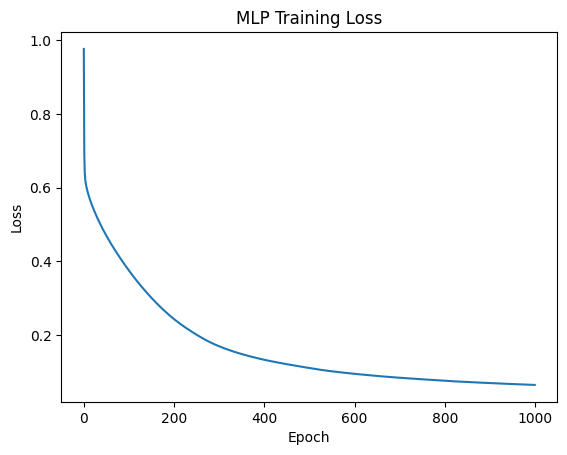

In [7]:
pred = np.argmax(forward(X)[0][-1], axis=1)

print("Accuracy:",
      np.mean(pred == y) * 100, "%")

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.show()